# Track A L1 parameter dictionary

Option A* fat torus $(r,R)=(8,50)$ nm with $\hbar c_s=0.07$ meV·µm and $\Delta_0=0.600$ meV. The gap-map coupling, Landau mass, GPE healing, catalyzon hybridisation, and Hall staircase are one dictionary. Hubbard, Chern–Simons in the GPE EOM, H-TOR1, and holographic $\gamma_{\mathrm{QM}}$ are out of scope.

Status tags: **locked** / **derived** / **matched** / **ansatz** / **computed**.

Three lengths exist and are never mixed:

- $a_H=r=8$ nm — Option A* GL/GPE healing freeze **[locked]**
- $\xi_{\mathrm{ph}}=\hbar c_s/\Delta_0$ — phonon healing; $\eta_{\mathrm{ret}}=2$ identically **[derived]**
- $\xi=0.181$ µm — preprint causal-propagator coherence that produced $\eta_{\mathrm{ret}}\approx 3.1$; numerically $\hbar c_s/\Delta_{\mathrm{QVC}}$ at the withdrawn $0.389$ meV. Alternate, not the lock.

Catalyzon is a parallel channel: $g_0=\lambda E_{\mathrm{vac}}$, $\Delta_{\mathrm{cat}}=\Delta_0-g_0$. Live gap $0.6305$ meV / $g^{(1)}=0.8832$ is the coherent GPE baseline.

In [1]:
import sys
from pathlib import Path
from IPython.display import display, Image, Markdown

ROOT = Path.cwd().resolve()
if ROOT.name == "l1_dictionary":
    ROOT = ROOT.parents[1]
elif (ROOT / "notebooks" / "l1_dictionary").is_dir():
    pass
else:
    ROOT = Path("/Users/mineralhoiland/Code/QVCCursor")
sys.path.insert(0, str(ROOT))

from qvc_l1.bootstrap import ensure_qvccompute
ensure_qvccompute()

from qvc_l1.dictionary import DEFAULT_OUT, run_all

OUT = ROOT / "notebooks" / "l1_dictionary" / "output"
OUT.mkdir(parents=True, exist_ok=True)
bundle = run_all(out_dir=OUT, make_figures=True)
locks = bundle["locks_obj"]
card = bundle["parameter_card"]
print("Option A* fat torus")
print(f"  (r,R)=({locks.r_um*1e3:.0f},{locks.R_um*1e3:.0f}) nm   ħc_s={locks.hbar_cs_meV_um} meV·µm")
print(f"  F={locks.F:.5f}   E_vac={locks.E_vac_meV:.4f} meV")
print(f"  λ★={locks.lambda_star:.4f}   g0★={card['g0_star_meV']:.4f} meV")
print(f"  a_H={card['a_H_um']:.3f} µm   η_ret(a_H)={card['eta_ret_a_H']:.3f}")
print(f"  ξ_ph={card['xi_ph_um']:.4f} µm   η_ret(ξ_ph)={card['eta_ret_xi_ph']:.0f}")
print(f"  κ_GL={card['kappa_GL_meV_um2']:.4e} meV·µm²")
print(f"  R_WS={card['R_WS_um']:.2f} µm at T*={card['T_star_mK']:.1f} mK")

Option A* fat torus
  (r,R)=(8,50) nm   ħc_s=0.07 meV·µm
  F=0.58068   E_vac=0.1287 meV
  λ★=0.7628   g0★=0.0982 meV
  a_H=0.008 µm   η_ret(a_H)=0.137
  ξ_ph=0.1167 µm   η_ret(ξ_ph)=2
  κ_GL=3.8400e-05 meV·µm²
  R_WS=2.18 µm at T*=118.7 mK


## Lengths and $\eta_{\mathrm{ret}}$

The retardation factor is the identity $\eta_{\mathrm{ret}}=2\Delta_0\xi/(\hbar c_s)$ once $\xi$ is chosen. With $\xi=a_H$ one has $\eta_{\mathrm{ret}}\approx 0.137$, not $2$. With $\xi=\xi_{\mathrm{ph}}$ one has $\eta_{\mathrm{ret}}=2$ identically. The preprint figure $3.1$ is $\xi=0.181$ µm and is not the unique lock.

a_H       0.00800 µm   η_ret=0.1371   [locked]  lock=True
xi_ph     0.11667 µm   η_ret=2.0000   [derived]  lock=False
xi_181    0.18100 µm   η_ret=3.1029   [alternate]  lock=False


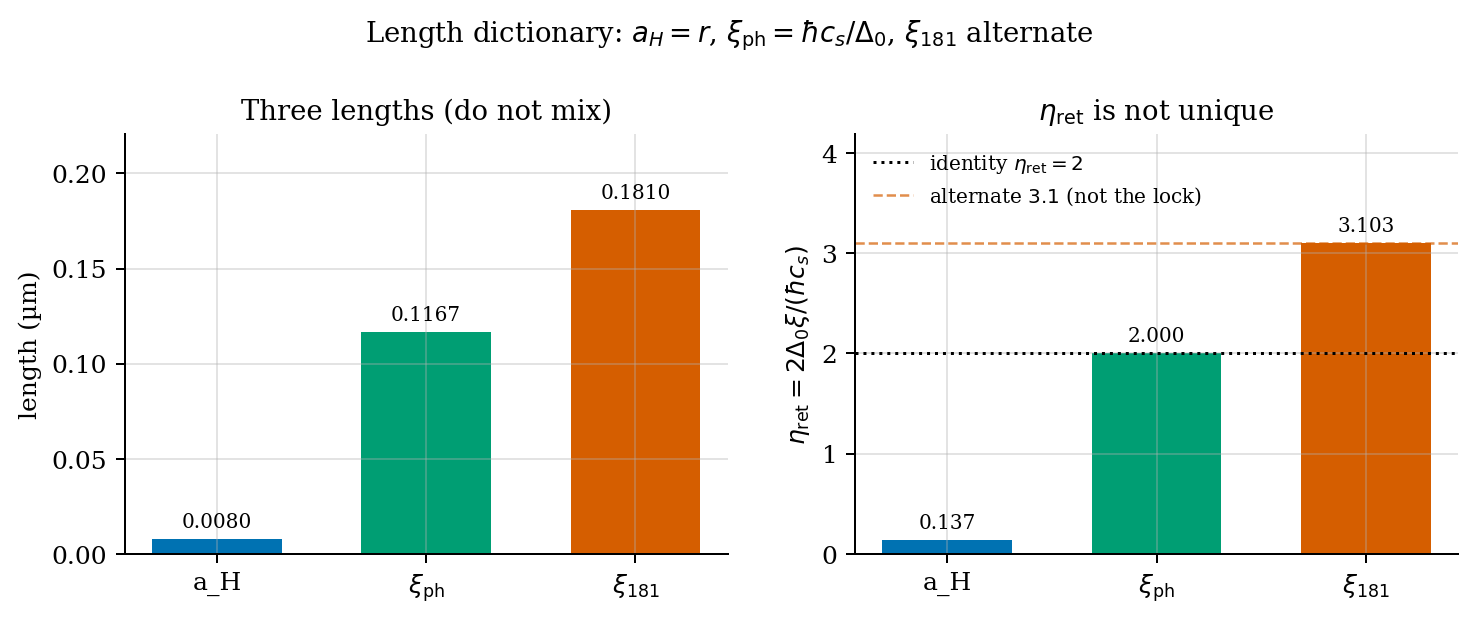

In [2]:
L = bundle["lengths"]["lengths"]
for name, row in L.items():
    print(f"{name:8s}  {row['value_um']:.5f} µm   η_ret={row['eta_ret']:.4f}   [{row['status']}]  lock={row['is_lock']}")
display(Image(str(OUT / "fig_lengths.png")))

## GL coefficients

The gap-map coupling $\alpha=\lambda E_{\mathrm{vac}}/\Delta_0$ is dimensionless. The Landau mass is $\alpha_{\mathrm{GL}}=-\Delta_0$. Gradient weight $\kappa_{\mathrm{GL}}=\Delta_0 a_H^2$ matches the truncated GPE kinetic coefficient. The quartic $\beta$ sits the Mexican-hat vacuum on the hopfion $n_{\mathrm{ref}}$. $\kappa_S$ is a Derrick ansatz on the locked tube, not holographic $\gamma_{\mathrm{QM}}$.

In [3]:
gl = bundle["gl"]
print(f"α(λ★)     = {gl['alpha_gap_map_star']['alpha']:.4f}   [{gl['alpha_gap_map_star']['status']}]")
print(f"α_GL      = {gl['alpha_GL']['value_meV']:.3f} meV   [{gl['alpha_GL']['status']}]")
print(f"κ_GL      = {gl['kappa_GL']['value_meV_um2']:.4e} meV·µm²   [{gl['kappa_GL']['status']}]")
print(f"n_ref     = {gl['n_ref']['n_ref']:.5f}   [{gl['n_ref']['status']}]")
print(f"β         = {gl['beta']['beta_meV']:.4f} meV   [{gl['beta']['status']}]")
print(f"κ_S       = {gl['kappa_S']['kappa_S_meV_um4']:.4e} meV·µm⁴   [{gl['kappa_S']['status']}]")
print(gl["kappa_S"]["ansatz_label"])

α(λ★)     = 0.1636   [derived]
α_GL      = -0.600 meV   [matched]
κ_GL      = 3.8400e-05 meV·µm²   [derived]
n_ref     = 0.86435   [computed]
β         = 0.6942 meV   [matched]
κ_S       = 2.4576e-09 meV·µm⁴   [ansatz]
Faddeev–Skyrme 3D Derrick on locked tube a_H; 2πR cancels


## Catalyzon and Spec$(G)$

$g_0=\lambda E_{\mathrm{vac}}$ at the same participation as the fold map. At $\lambda^\star$ this is $g_0^\star\approx 0.0982$ meV ($\Delta_{\mathrm{cat}}\approx 0.502$ meV, $\sim 16.4\%$). At $\lambda_{\mathrm{fold}}$, $g_0=\Delta_c$ and the reduction is $\alpha_c$. Democratic $\lambda_{\min}=-g_0$ with multiplicity $N-1$. Do not stack with fold or live-gap percentages. $g_0\sim 0.21$ is not derived.

lambda_star     λ=0.7628  g0=0.0982 meV  Δ_cat=0.5018 meV  (16.4%)
lambda_fold     λ=0.8475  g0=0.1091 meV  Δ_cat=0.4909 meV  (18.2%)
λ_min = −g0: True
eigs at g0★: [-0.09816962498385384, -0.09816962498385381, -0.09816962498385381, -0.09816962498385379, 0.39267849993541526]


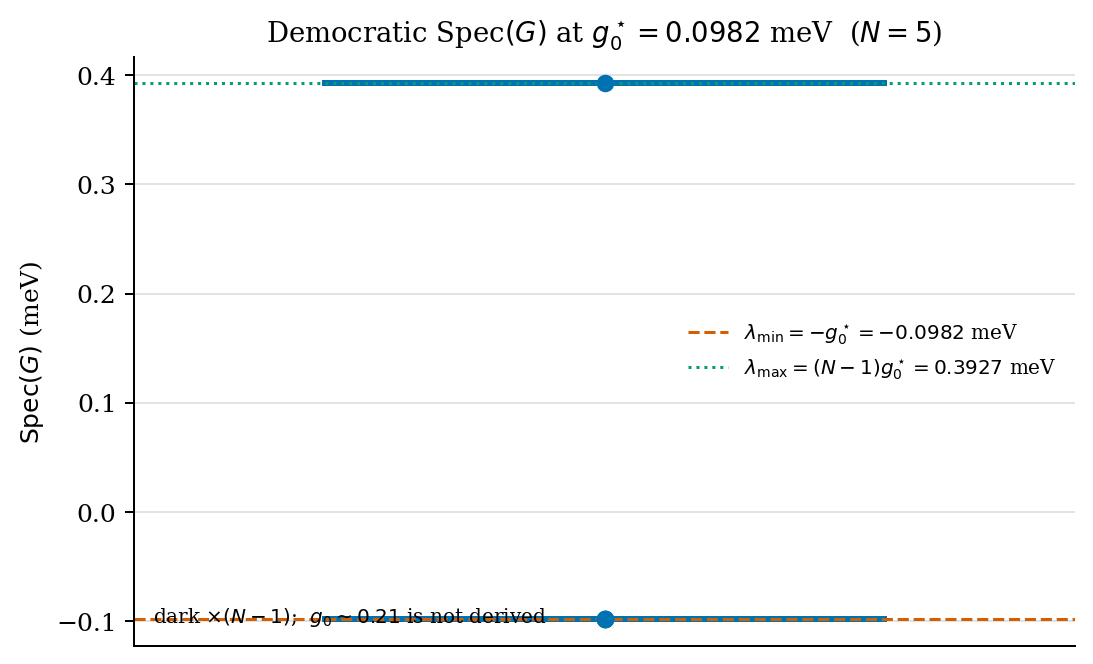

In [4]:
cat = bundle["catalyzon"]
for key in ("at_lambda_star", "at_lambda_fold"):
    row = cat[key]
    print(
        f"{row['label']:14s}  λ={row['lambda']:.4f}  g0={row['g0_meV']:.4f} meV  "
        f"Δ_cat={row['Delta_cat_meV']:.4f} meV  ({row['reduction_pct']:.1f}%)"
    )
print("λ_min = −g0:", cat["lambda_min_equals_minus_g0"])
print("eigs at g0★:", cat["at_lambda_star"]["spec"]["eigs_numerical_meV"])
display(Image(str(OUT / "fig_spec_G.png")))

## Mexican hat

$V(\rho)=\alpha_{\mathrm{GL}}\rho^2+(\beta/2)\rho^4-\lambda^\star E_{\mathrm{vac}}\rho^2$ on the GPE $\rho$ axis. The GPE-sign vacuum term is attractive and deepens the well. The parallel catalyzon channel dresses the Landau mass, $|\alpha|\to\Delta_{\mathrm{cat}}$, and the well-depth ratio $1-(\Delta_{\mathrm{cat}}/\Delta_0)^2$ replaces the cartoon $42\%$.

GPE-sign well-depth change: 35.4% (deepens=True)
Catalyzon-dressed barrier reduction: 30.0% (replaces cartoon 42%)


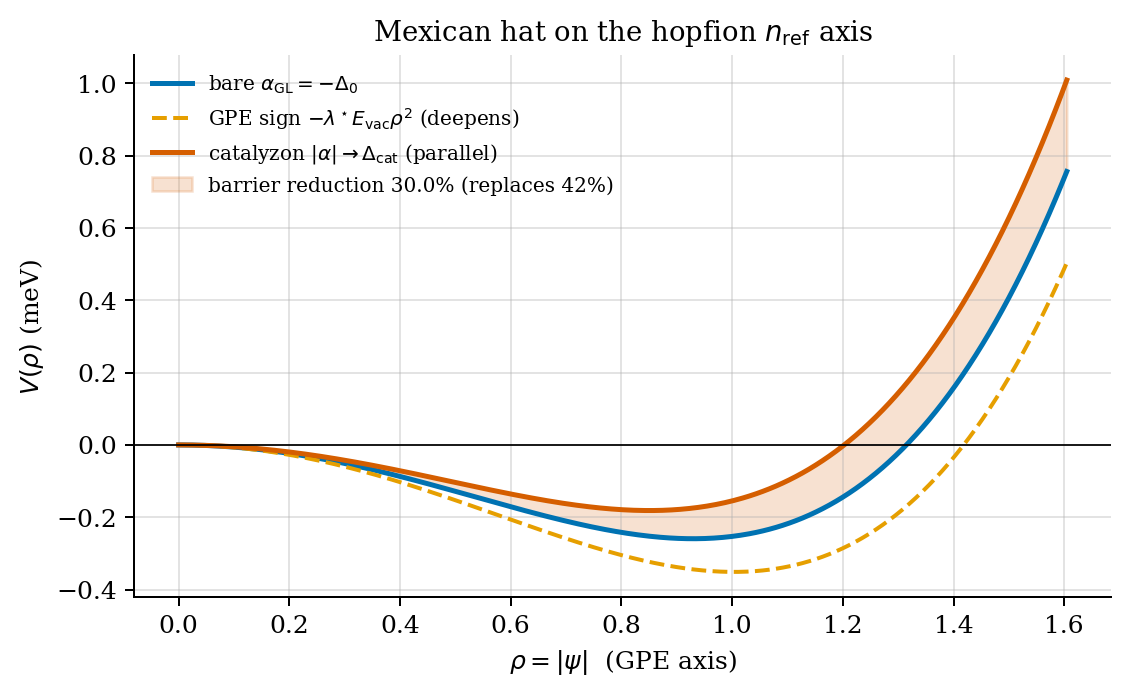

In [5]:
hat = bundle["mexican_hat"]
print(
    f"GPE-sign well-depth change: {100*hat['gpe_sign_shift']['depth_change_frac']:.1f}% "
    f"(deepens={hat['gpe_sign_shift']['well_deepens']})"
)
print(
    f"Catalyzon-dressed barrier reduction: {hat['catalyzon_dressed']['barrier_reduction_pct']:.1f}% "
    f"(replaces cartoon 42%)"
)
display(Image(str(OUT / "fig_mexican_hat.png")))

## Hall staircase and $R_{\mathrm{WS}}$ matching

One Chern–Simons convention: $k=2N$, $Q_H=1/N$, pairing $k Q_H=2$. Parent Hall conductivity $\sigma_{xy}=(k/2)e^2/h=N e^2/h$. Staircase step $\delta\sigma_{xy}=e^2/(k h)=Q_H e^2/(2h)$. Algebra only.

$R_{\mathrm{WS}}=\hbar c_s/(\pi k_B T^*)$ is analogue Hawking matching, not a duality. Berry $R_{\mathrm{mean}}\approx 0.908$ is a GOE/GUE ratio, not a radius.

In [6]:
hall = bundle["hall"]
ac = bundle["acoustic"]
print(f"k={hall['k_CS']}  Q_H={hall['Q_H']}  k Q_H={hall['pairing_k_QH']:.0f}")
print(f"δσ_xy = {hall['delta_sigma_xy_S']:.4e} S")
print(f"σ_xy parent = {hall['sigma_xy_parent_S']:.4e} S")
print(f"R_WS(T*) = {ac['R_WS_um']:.3f} µm   [matched, not duality]")
print(f"R_WS(285 mK) = {ac['R_WS_withdrawn_285mK_um']:.3f} µm  (withdrawn T*)")
print(f"Berry R_mean = {ac['Berry_R_mean']:.3f}  (ratio, not a radius)")

k=10  Q_H=0.2  k Q_H=2
δσ_xy = 3.8740e-06 S
σ_xy parent = 1.9370e-04 S
R_WS(T*) = 2.179 µm   [matched, not duality]
R_WS(285 mK) = 0.907 µm  (withdrawn T*)
Berry R_mean = 0.908  (ratio, not a radius)


## Parameter card

In [7]:
display(Markdown((OUT / "summary.md").read_text()))
print("Wrote", OUT / "summary.json")
print("Figures:")
for p in bundle.get("figures", []):
    print(" ", p)

# Track A L1 parameter dictionary

Fat-torus Option A* working point. Three lengths are distinct. Catalyzon is a parallel channel (not stacked with fold or live-gap). Hall algebra uses CS level $k=2N$ with $Q_H=1/N$.

## Parameter card

- $(r,R)=(8,50)$ nm, $\hbar c_s=0.07$ meV·µm, $\Delta_0=0.600$ meV  **[locked]**
- $F=0.58068$, $E_{\mathrm{vac}}=0.1287$ meV, $\alpha_c=\delta_c=0.1818$, $\Delta_c=0.1091$ meV  **[locked / derived]**
- $\lambda_{\mathrm{fold}}=0.8475$, $\lambda^\star=0.7628$, $\Delta^\star=0.2324$ meV  **[derived / locked]**
- $T^*=118.7$ mK, $E_{\mathrm{pair}}=0.1963$ meV, $N=5$, $Q_H=0.2$, $k=10$  **[computed / locked]**

### Lengths

- $a_H=r=0.008$ µm $=8$ nm, $\eta_{\mathrm{ret}}(a_H)=0.137$  **[locked]**
- $\xi_{\mathrm{ph}}=\hbar c_s/\Delta_0=0.1167$ µm, $\eta_{\mathrm{ret}}(\xi_{\mathrm{ph}})=2$ identically  **[derived]**
- $\xi_{181}=0.181$ µm (alternate; preprint coherence $\hbar c_s/\Delta_{\mathrm{QVC}}$), $\eta_{\mathrm{ret}}=3.10$  **[alternate, not the lock]**

### GL coefficients (matched, not Hubbard)

- $\alpha=\lambda^\star E_{\mathrm{vac}}/\Delta_0=0.1636$  **[derived]**
- $\alpha_{\mathrm{GL}}=-\Delta_0=-0.600$ meV  **[matched]**
- $\kappa_{\mathrm{GL}}=\Delta_0 a_H^2=3.8400e-05$ meV·µm$^2$  **[derived]**
- $\lambda=\lambda^\star=0.7628$  **[locked]**
- $n_{\mathrm{ref}}=0.86435$ on hopfion_initial  **[computed]**
- $\beta=\Delta_0/n_{\mathrm{ref}}=0.6942$ meV  **[matched]**
- $\kappa_S\approx\Delta_0 a_H^4=2.4576e-09$ meV·µm$^4$  **[ansatz]**

### Catalyzon (parallel channel)

- $g_0^\star=\lambda^\star E_{\mathrm{vac}}=0.0982$ meV, $\Delta_{\mathrm{cat}}=0.5018$ meV (16.4%)  **[derived]**
- at $\lambda_{\mathrm{fold}}$: $g_0=\Delta_c=0.1091$ meV (18.2%=$\alpha_c$)  **[derived]**
- Spec$(G)$: $\lambda_{\min}=-g_0^\star$, multiplicity $N-1=4$  **[locked algebra]**

### Mexican hat

- GPE-sign well-depth change: 35.4% (attractive $V_{\mathrm{ZPF}}$, well deepens)  **[computed]**
- Catalyzon-dressed barrier reduction: 30.0% $=1-(\Delta_{\mathrm{cat}}/\Delta_0)^2$ (replaces cartoon 42%)  **[computed]**

### Hall and matching

- $\delta\sigma_{xy}=e^2/(k h)=3.8740e-06$ S, parent $\sigma_{xy}=(k/2)e^2/h=1.9370e-04$ S  **[derived]**
- $R_{\mathrm{WS}}=\hbar c_s/(\pi k_B T^*)=2.18$ µm  **[matched]**
- Berry $R_{\mathrm{mean}}=0.908$ is a ratio, not a radius  **[computed]**

### Coherent GPE baseline (Lindblad is another agent)

- $\Delta_{\mathrm{live}}(1\,\mathrm{ps})=0.6305$ meV, $g^{(1)}=0.8832$  **[computed]**

## Status ledger

### locked
- fat torus (r,R)=(8,50) nm, ħ c_s=0.07 meV·µm, Δ₀=0.600 meV
- a_H = r (Option A* GL/GPE healing freeze)
- η_ret = 2 Δ₀ ξ / (ħ c_s) as algebra (ξ remains a choice)
- λ★ = 0.90 λ_fold, N=5, Q_H=1/N, k=2N
- F, E_vac, α_c=δ_c, Δ_c from the frozen-cavity bridge

### derived
- ξ_ph = ħ c_s / Δ₀ and η_ret(ξ_ph)=2
- η_ret(a_H)=2 Δ₀ a_H/(ħ c_s)≈0.137
- κ_GL = Δ₀ a_H²
- α = λ E_vac / Δ₀ (gap-map coupling)
- g0 = λ E_vac, Δ_cat = Δ₀ − g0, Spec(G): λ_min=−g0
- λ_fold = α_c Δ₀ / E_vac
- Hall: k=2N, δσ_xy = e²/(k h) = Q_H e²/(2h)
- pairing k Q_H = 2

### matched
- α_GL = −Δ₀ (Landau mass |α_GL|=Δ₀)
- β = Δ₀ / n_ref so the Mexican-hat vacuum sits on hopfion n_ref
- R_WS = ħ c_s/(π k_B T*) at T* (analogue Hawking matching, not duality)

### ansatz
- κ_S ≈ κ_GL a_H² = Δ₀ a_H⁴ (Derrick balance on the locked tube)

### computed
- n_ref from hopfion_initial (ring-weighted |ψ|²)
- Mexican-hat well depths and catalyzon barrier reduction
- T*, E_pair from Schwinger twin-channel at g0★
- live gap 0.6305 meV / g(1)=0.8832 coherent GPE baseline (not rerun here)
- Berry R_mean≈0.908 (ratio, not a radius)

### alternate_not_lock
- ξ=0.181 µm → η_ret≈3.1 (preprint coherence; ħ c_s/Δ_QVC withdrawn)
- R_WS(285 mK)≈0.91 µm (same matching formula, withdrawn T*)

### retired
- g0~0.21 as a derived coupling
- κ_tor≈0.25 as an insertion
- cartoon α0=−0.5, α_QVC=−0.35, 42% barrier drop
- holographic γ_QM≈3.73 meV·nm² as κ_GL
- folklore 0.244 / 0.389 / 0.032 / 92%

### out_of_scope
- Hubbard microscopic derivation of GL coefficients
- Chern–Simons in the GPE EOM
- H-TOR1 torsion vertex
- holographic dictionary

## Notes

- Democratic $\lambda_{\min}=-g_0$ check: True.
- $n_{\mathrm{ref}}$ formula: n_ref = ⟨|ψ|²⟩_{ring} on hopfion_initial.
- $\kappa_S$ ansatz: Faddeev–Skyrme 3D Derrick on locked tube a_H; 2πR cancels.
- Do not stack catalyzon, fold, and live-gap percentages.
- Do not box $\eta_{\mathrm{ret}}=3.1$ as the unique lock.
- Retired insertions: $g_0\sim0.21$ meV, $\kappa_{\mathrm{tor}}\approx0.25$.



Wrote /Users/mineralhoiland/Code/QVCCursor/notebooks/l1_dictionary/output/summary.json
Figures:
  /Users/mineralhoiland/Code/QVCCursor/notebooks/l1_dictionary/output/fig_lengths.png
  /Users/mineralhoiland/Code/QVCCursor/notebooks/l1_dictionary/output/fig_mexican_hat.png
  /Users/mineralhoiland/Code/QVCCursor/notebooks/l1_dictionary/output/fig_spec_G.png
